# Student Performance Prediction in Bangladesh
This notebook demonstrates a complete machine learning pipeline to predict HSC results based on student demographics, family background, and previous academic performance (SSC results).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading and Initial Exploration
In this section, we load the dataset and perform a quick check of the data structure, including shapes, samples, and summary statistics to understand the features we are working with.

In [96]:
# Load the student performance dataset from a CSV file
df = pd.read_csv("bangladesh_student_performance_updated.csv")

In [ ]:
df.shape

(2068, 16)

In [ ]:
df.sample(10)

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
1666,29/04/2018,M,19.0,Urban,LE3,Together,3,0,Teacher,Services,No,No,117535,4,4.95,4.38
1735,29/04/2018,F,17.0,Rural,GT3,Together,2,3,Other,Services,No,No,36745,1,4.08,3.59
544,29/04/2018,F,NaN,Rural,GT3,Apart,0,4,Services,Services,No,No,42400,1,NaN,3.08
1787,29/04/2018,F,18.0,Urban,GT3,Together,1,3,Services,Teacher,Yes,No,90158,1,3.91,3.06
115,29/04/2018,F,17.0,Rural,GT3,Together,1,2,Teacher,Farmer,No,No,51191,5,4.24,3.40
1880,29/04/2018,F,19.0,Rural,LE3,Together,4,4,Teacher,Health,No,No,83464,4,4.07,3.78
1538,29/04/2018,M,19.0,Rural,LE3,Together,1,2,Health,Teacher,No,No,45860,4,3.82,3.14
1935,29/04/2018,F,19.0,Urban,GT3,Together,1,2,Teacher,Business,No,No,87178,1,3.60,3.16
199,29/04/2018,F,19.0,Rural,GT3,Together,3,2,NaN,Business,No,No,52550,5,4.19,3.47
1974,29/04/2018,M,19.0,Rural,GT3,Together,2,2,Teacher,Services,No,No,45974,4,4.08,3.48


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2068 entries, 0 to 2067
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          2068 non-null   object 
 1   gender        2068 non-null   object 
 2   age           1917 non-null   float64
 3   address       2068 non-null   object 
 4   famsize       2068 non-null   object 
 5   Pstatus       2068 non-null   object 
 6   M_Edu         2068 non-null   int64  
 7   F_Edu         2068 non-null   int64  
 8   M_Job         1963 non-null   object 
 9   F_Job         2068 non-null   object 
 10  relationship  2068 non-null   object 
 11  smoker        2068 non-null   object 
 12  tuition_fee   2068 non-null   int64  
 13  time_friends  2068 non-null   int64  
 14  ssc_result    1963 non-null   float64
 15  hsc_result    2068 non-null   float64
dtypes: float64(3), int64(4), object(9)
memory usage: 258.6+ KB


In [ ]:
df['time_friends'].unique()
df['M_Edu'].unique()
df['famsize'].unique()

array(['GT3', 'LE3'], dtype=object)

In [ ]:
df.isnull().sum()

,0
date,0
gender,0
age,151
address,0
famsize,0
Pstatus,0
M_Edu,0
F_Edu,0
M_Job,105
F_Job,0


In [ ]:
df.describe()

,age,M_Edu,F_Edu,tuition_fee,time_friends,ssc_result,hsc_result
count,1917.000000,2068.000000,2068.000000,2068.000000,2068.000000,1963.000000,2068.000000
mean,17.976526,1.868956,2.165861,73012.346228,3.060928,3.786556,3.198046
std,0.826853,1.193331,1.255103,24013.068516,1.439024,0.622169,0.604337
min,17.000000,0.000000,0.000000,25102.000000,1.000000,2.000000,2.000000
25%,17.000000,1.000000,1.000000,53658.000000,2.000000,3.350000,2.770000
50%,18.000000,2.000000,2.000000,71272.500000,3.000000,3.770000,3.160000
75%,19.000000,3.000000,3.000000,91035.000000,4.000000,4.230000,3.580000
max,19.000000,4.000000,4.000000,129168.000000,5.000000,5.000000,5.000000


## 2. Exploratory Data Analysis (EDA)
Visualizing the data helps us identify patterns, correlations between features, and potential outliers. We look at the distribution of numerical features and the relationship between our target variable (`hsc_result`) and other predictors.

In [97]:
# Check for duplicate rows in the dataset
print(f"Initial duplicate count: {df.duplicated().sum()}")

# Remove duplicate rows to ensure data quality
df.drop_duplicates(inplace=True)

# Verify that duplicates have been removed
print(f"Duplicate count after removal: {df.duplicated().sum()}")

Initial duplicate count: 50
Duplicate count after removal: 0


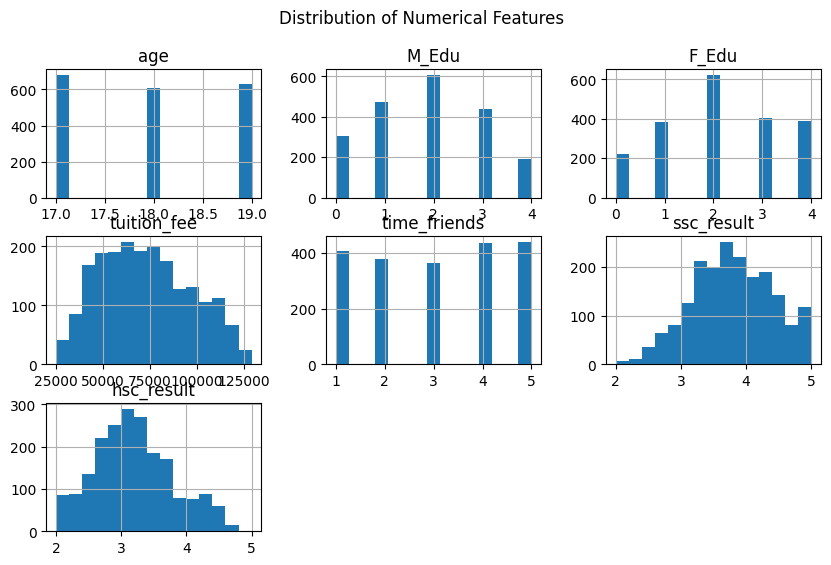

In [103]:
# Generate histograms for all numerical features to visualize their distributions
# 'bins=15' controls the number of bars, and 'figsize' sets the display dimensions
df.hist(bins=15, figsize=(10,6))

plt.suptitle("Distribution of Numerical Features")
plt.show()

In [ ]:
numerical_cols = ['age','tuition_fee','ssc_result','hsc_result']



df[numerical_cols].corr()

,age,tuition_fee,ssc_result,hsc_result
age,1.000000,-0.004211,-0.012598,-0.019616
tuition_fee,-0.004211,1.000000,0.014670,0.038068
ssc_result,-0.012598,0.014670,1.000000,0.949661
hsc_result,-0.019616,0.038068,0.949661,1.000000


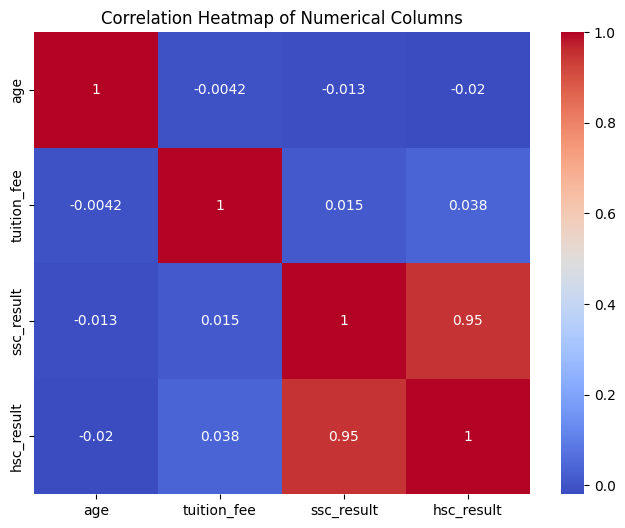

In [104]:
# Create a heatmap to visualize the Pearson correlation coefficients between numerical columns
# 'annot=True' displays the correlation values on the map
plt.figure(figsize=(8,6))

sns.heatmap(
    df[numerical_cols].corr(),
    annot = True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

<Axes: xlabel='ssc_result'>

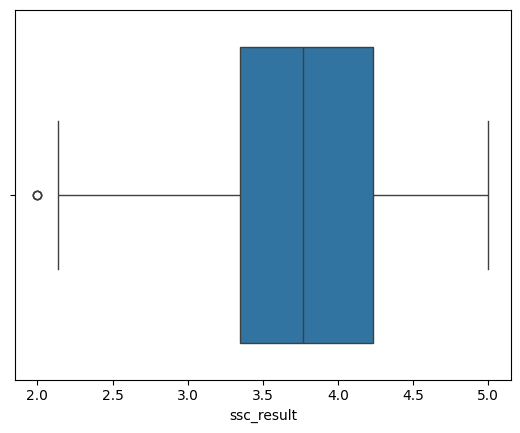

In [ ]:
sns.boxplot(data=df , x="ssc_result")

# preprocessing

Preprocessing is a critical step where we handle missing values, encode categorical variables (nominal and ordinal), and scale numerical features to prepare them for the machine learning models.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.pipeline import Pipeline

In [98]:
# Categorize features for specific preprocessing treatments
# Nominal categories: features with no inherent mathematical order
nominal_cat = ['gender','address','famsize','Pstatus','relationship','smoker','F_Job','M_Job']

# Numerical columns: continuous values that require scaling and imputation
numerical_col = ['age','tuition_fee','ssc_result']

In [99]:
# Pipeline for numerical features:
# 1. Fill missing values using the mean of the column
# 2. Standardize features scaling
numerical_transformers = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)

In [100]:
# Pipeline for categorical features:
# 1. Fill missing values with the most frequent category
# 2. Convert categories  (one-hot encoding)
nominal_transformers = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
    ]
)

In [ ]:
# ordinal_transformers = Pipeline(
#     steps=[
#         ('imputer', SimpleImputer(strategy='most_frequent')),
#         ('encoder',OrdinalEncoder(categories=[M_edu_order,F_edu_order,time_friends_order])),
#         ('scaler',MinMaxScaler())
#     ]
# )

In [101]:
# Combine all transformations into a single preprocessor
# This applies specific pipelines to the designated columns automatically
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical', numerical_transformers, numerical_col),
        ('nominal', nominal_transformers, nominal_cat)
    ],
    remainder="passthrough" # Keep columns not specified in the transformers
)

In [102]:
# Split features (X) and target (y)
X = df.drop(['date', 'hsc_result'], axis=1)
y = df['hsc_result']

# Split the data into training (80%) and testing (20%) sets
# random_state ensures reproducibility of the results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 3. Model Training
We evaluate two different linear regression models to see which one performs better on this specific dataset:
1. **Linear Regression**: A standard approach for regression tasks.
2. **SGD Regressor**: Uses Stochastic Gradient Descent, which is efficient for larger datasets.

# LinearRegression

In [ ]:
from sklearn.linear_model import LinearRegression,SGDRegressor

In [105]:
# Initialize the Linear Regression pipeline
# This combines our preprocessing steps with the Linear Regression algorithm
lr_pipe=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model' , LinearRegression())
    ]
)

# Train (fit) the Linear Regression model using the training data
lr_pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'F_Job', 'M_Job'])])),
                ('model', LinearRegression())])

In [ ]:
X_test

,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result
1556,F,NaN,Rural,GT3,Together,1,1,At_home,Teacher,Yes,No,52743,1,3.88
526,M,NaN,Rural,GT3,Together,4,3,At_home,Business,No,No,58678,5,4.36
393,F,NaN,Urban,GT3,Together,2,1,Services,Services,No,No,115832,3,NaN
1789,M,NaN,Urban,GT3,Together,2,3,Health,Teacher,No,Yes,112781,1,4.43
433,M,NaN,Rural,LE3,Together,1,0,Teacher,Farmer,No,Yes,52481,4,4.71
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1112,M,17.0,Rural,GT3,Apart,1,4,Health,Teacher,No,No,60345,4,3.47
693,M,19.0,Urban,GT3,Together,1,2,Health,Business,No,No,85346,4,2.96
1494,F,18.0,Rural,LE3,Together,1,4,NaN,Teacher,No,No,30638,1,3.76
921,M,19.0,Urban,GT3,Together,0,1,Teacher,Teacher,No,No,76804,2,4.18


In [ ]:
lr_pipe.predict(X_test)

array([3.22923633, 3.75998154, 3.20540131, 4.01556809, 3.90100923,
       3.32858986, 3.99982234, 2.55130135, 1.96339155, 3.27533719,
       3.67172456, 2.92665892, 3.26413973, 4.28470275, 3.02827272,
       2.6811151 , 3.71377389, 3.46144581, 2.81167542, 2.95959852,
       2.81202158, 3.20791055, 3.009379  , 3.20873141, 1.89496267,
       2.60178496, 3.17559187, 3.84716223, 3.36387774, 3.96761919,
       2.39327511, 3.94339451, 4.32354472, 2.57423836, 3.19630456,
       3.47698745, 2.75139513, 3.63585208, 2.49852416, 2.6043745 ,
       3.06553132, 2.97368217, 3.73770498, 2.79081789, 2.16463328,
       3.07189775, 2.59458183, 2.61379814, 4.03391001, 3.15928512,
       3.079236  , 3.4441778 , 4.25115939, 3.63266626, 3.06650827,
       3.21729716, 3.26142437, 2.68495188, 3.80611247, 2.70270458,
       2.98676998, 2.77106969, 2.4965389 , 4.44625236, 2.53824493,
       3.22193569, 3.97026945, 2.67665605, 3.0134797 , 3.21054146,
       3.02338835, 2.73648336, 2.60832188, 3.61242412, 3.06903

In [106]:
# Initialize the Stochastic Gradient Descent (SGD) Regressor pipeline
# SGD is an optimization technique often used for large-scale learning
SGD_pipe=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model' , SGDRegressor())
    ]
)

# Train the SGD model
SGD_pipe.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'tuition_fee',
                                                   'ssc_result']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'address',
                                                   'famsize', 'Pstatus',
                                                   'relationship', 'smoker',
                                                   'F_Job', 'M_Job'])])),
                ('model', SGDRegressor())])

In [ ]:
SGD_pipe.predict(X_test)

array([3.21272823, 3.76576266, 3.19577488, 3.95658252, 3.82400678,
       3.33335014, 3.95774869, 2.52067379, 1.9355229 , 3.27764534,
       3.66862032, 2.92222207, 3.25613391, 4.27813136, 3.02487178,
       2.63984726, 3.71319631, 3.40892379, 2.80388185, 2.92267498,
       2.79830718, 3.21112495, 2.95571597, 3.16570305, 1.87898368,
       2.51447014, 3.18088437, 3.8471893 , 3.32577134, 3.97188226,
       2.37793165, 3.94908142, 4.27859141, 2.57122252, 3.19718124,
       3.50519596, 2.74278501, 3.64281958, 2.50690231, 2.61071231,
       3.07370861, 2.97085571, 3.73151138, 2.79673875, 2.10833653,
       3.0768704 , 2.60566714, 2.59009036, 3.98137908, 3.11670784,
       3.06316682, 3.43524007, 4.22416862, 3.60176355, 3.04642236,
       3.16158616, 3.26505611, 2.67712807, 3.80269606, 2.63571595,
       2.99034853, 2.76215577, 2.46820719, 4.45586213, 2.53501152,
       3.21755229, 3.92425171, 2.67701807, 3.00726024, 3.16596064,
       3.01055921, 2.74324109, 2.60257951, 3.61605255, 3.05367

### Accuracy of the models

In [ ]:
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error

In [107]:
# --- Linear Regression Evaluation ---
# Predict HSC results for the test set
y_pred = lr_pipe.predict(X_test)

# Calculate and print performance metrics
# MSE/RMSE: measure error magnitude; R2: measures explained variance; MAE: measures average error
print(f"MSE: {round(mean_squared_error(y_test, y_pred), 4)}")
print(f"R2: {round(r2_score(y_test, y_pred), 4)}")
print(f"RMSE: {round(root_mean_squared_error(y_test, y_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred), 4)}")

MSE: 0.0377
R2: 0.8995
RMSE: 0.1941
MAE: 0.1321


In [108]:
# --- SGD Regression Evaluation ---
# Predict HSC results using the SGD model
y_pred = SGD_pipe.predict(X_test)

# Compare these results with the standard Linear Regression model
print(f"MSE: {round(mean_squared_error(y_test, y_pred), 4)}")
print(f"R2: {round(r2_score(y_test, y_pred), 4)}")
print(f"RMSE: {round(root_mean_squared_error(y_test, y_pred), 4)}")
print(f"MAE: {round(mean_absolute_error(y_test, y_pred), 4)}")

MSE: 0.0382
R2: 0.8981
RMSE: 0.1955
MAE: 0.1359


## 4. Final Evaluation
We compare the performance of the models using metrics like Mean Squared Error (MSE), R-squared (R2), and Mean Absolute Error (MAE). These metrics tell us how close our predictions are to the actual student results.